# 4. Fusion des datasets — Construction du DataFrame unifié

Ce notebook montre comment relier les 4 sources de données entre elles
via la clé commune `EmployeeID` et produit un DataFrame final prêt à l'analyse.

## Schéma des liens entre datasets

```
                         ┌─────────────────────────┐
                         │   general_data.csv      │
                         │   (24 colonnes)         │
                         │   Clé : EmployeeID      │
                         └────────┬────────────────┘
                                  │
                    EmployeeID (inner join)
                 ┌────────────────┼────────────────┐
                 │                │                 │
    ┌────────────▼──────┐  ┌─────▼──────────┐  ┌──▼──────────────────┐
    │ employee_survey   │  │ manager_survey │  │ in_out_time/        │
    │ _data.csv         │  │ _data.csv      │  │ (in_time, out_time) │
    │                   │  │                │  │                     │
    │ Clé: EmployeeID   │  │ Clé: EmployeeID│  │ Clé: index (=EmpID)│
    │ 3 cols satisfaction│  │ 2 cols évaluat.│  │ → agrégé en 6 cols │
    └───────────────────┘  └────────────────┘  └─────────────────────┘
```

**Type de jointure** : toutes les jointures se font sur `EmployeeID` :
- **general_data** ↔ **employee_survey** : relation 1:1 via `EmployeeID`
- **general_data** ↔ **manager_survey** : relation 1:1 via `EmployeeID`
- **general_data** ↔ **in_out_time** : relation 1:1 via `EmployeeID` (index des fichiers CSV)

Les 4 fichiers contiennent exactement les mêmes 4410 employés.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 4.1 Chargement de tous les datasets

In [2]:
# 1. Données RH générales
df_general = pd.read_csv("data/general_data.csv")
print(f"general_data       : {df_general.shape}")

# 2. Enquête employé
df_emp_survey = pd.read_csv("data/employee_survey_data.csv")
print(f"employee_survey    : {df_emp_survey.shape}")

# 3. Évaluation manager
df_mgr_survey = pd.read_csv("data/manager_survey_data.csv")
print(f"manager_survey     : {df_mgr_survey.shape}")

# 4. Horaires de badgeage → agrégation
df_in = pd.read_csv("data/in_out_time/in_time.csv", index_col=0)
df_out = pd.read_csv("data/in_out_time/out_time.csv", index_col=0)
print(f"in_time            : {df_in.shape}")
print(f"out_time           : {df_out.shape}")

general_data       : (4410, 24)
employee_survey    : (4410, 4)
manager_survey     : (4410, 3)
in_time            : (4410, 261)
out_time           : (4410, 261)


## 4.2 Vérification de la cohérence des `EmployeeID`

Avant toute jointure, on vérifie que les 4 sources couvrent les mêmes employés.

In [3]:
ids_general = set(df_general["EmployeeID"])
ids_emp = set(df_emp_survey["EmployeeID"])
ids_mgr = set(df_mgr_survey["EmployeeID"])
ids_time = set(df_in.index)

all_ids = [ids_general, ids_emp, ids_mgr, ids_time]
names = ["general_data", "employee_survey", "manager_survey", "in_out_time"]

print("Nombre d'EmployeeID par source :")
for name, ids in zip(names, all_ids):
    print(f"  {name:20s} : {len(ids)}")

common = ids_general & ids_emp & ids_mgr & ids_time
print(f"\nIntersection (présents partout) : {len(common)}")
print(f"Union totale                    : {len(ids_general | ids_emp | ids_mgr | ids_time)}")

Nombre d'EmployeeID par source :
  general_data         : 4410
  employee_survey      : 4410
  manager_survey       : 4410
  in_out_time          : 4410

Intersection (présents partout) : 4410
Union totale                    : 4410


## 4.3 Agrégation des données de badgeage

Les fichiers `in_time` / `out_time` contiennent 261 colonnes-dates.
On les agrège en indicateurs par employé avant la jointure.

In [4]:
# Conversion en datetime
df_in_dt = df_in.apply(pd.to_datetime, errors="coerce")
df_out_dt = df_out.apply(pd.to_datetime, errors="coerce")

# Durée de travail en heures
df_duration = (df_out_dt - df_in_dt).apply(lambda col: col.dt.total_seconds() / 3600)

# Heures d'arrivée et de départ
df_in_hours = df_in_dt.apply(lambda col: col.dt.hour + col.dt.minute / 60)
df_out_hours = df_out_dt.apply(lambda col: col.dt.hour + col.dt.minute / 60)

# Construction du DataFrame agrégé
df_time_features = pd.DataFrame({
    "EmployeeID": df_in.index,
    "avg_in_hour": df_in_hours.mean(axis=1).values,
    "avg_out_hour": df_out_hours.mean(axis=1).values,
    "avg_work_hours": df_duration.mean(axis=1).values,
    "std_work_hours": df_duration.std(axis=1).values,
    "nb_days_present": df_duration.notna().sum(axis=1).values,
    "nb_days_absent": df_duration.isna().sum(axis=1).values,
})

print(f"Features temporelles : {df_time_features.shape}")
df_time_features.head()

Features temporelles : (4410, 7)


,EmployeeID,avg_in_hour,avg_out_hour,avg_work_hours,std_work_hours,nb_days_present,nb_days_absent
0,1,9.993032,17.367170,7.373651,0.283224,232,29
1,2,9.980720,17.698446,7.718969,0.313351,236,25
2,3,10.016598,17.030096,7.013240,0.311551,242,19
3,4,9.973830,17.167305,7.193678,0.284133,235,26
4,5,9.990068,17.996327,8.006175,0.300656,245,16


## 4.4 Jointures successives

On fusionne les 4 sources étape par étape via `pd.merge()` sur `EmployeeID`.
On utilise un **left join** en partant de `general_data` (table de référence)
pour conserver tous les employés même en cas de données manquantes dans les enquêtes.

In [5]:
# Étape 1 : general_data + employee_survey
df = df_general.merge(df_emp_survey, on="EmployeeID", how="left")
print(f"Après merge general + employee_survey : {df.shape}")

# Étape 2 : + manager_survey
df = df.merge(df_mgr_survey, on="EmployeeID", how="left")
print(f"Après merge + manager_survey          : {df.shape}")

# Étape 3 : + features temporelles (badgeage)
df = df.merge(df_time_features, on="EmployeeID", how="left")
print(f"Après merge + time_features           : {df.shape}")

Après merge general + employee_survey : (4410, 27)
Après merge + manager_survey          : (4410, 29)
Après merge + time_features           : (4410, 35)


In [6]:
df.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,avg_in_hour,avg_out_hour,avg_work_hours,std_work_hours,nb_days_present,nb_days_absent
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,1,Healthcare Representative,Married,131160,1.0,Y,11,8,0,1.0,6,1,0,0,3.0,4.0,2.0,3,3,9.993032,17.367170,7.373651,0.283224,232,29
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,1,Research Scientist,Single,41890,0.0,Y,23,8,1,6.0,3,5,1,4,3.0,2.0,4.0,2,4,9.980720,17.698446,7.718969,0.313351,236,25
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,4,Sales Executive,Married,193280,1.0,Y,15,8,3,5.0,2,5,0,3,2.0,2.0,1.0,3,3,10.016598,17.030096,7.013240,0.311551,242,19
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,3,Human Resources,Married,83210,3.0,Y,11,8,3,13.0,5,8,7,5,4.0,4.0,3.0,2,3,9.973830,17.167305,7.193678,0.284133,235,26
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,1,Sales Executive,Single,23420,4.0,Y,12,8,2,9.0,2,6,0,4,4.0,1.0,3.0,3,3,9.990068,17.996327,8.006175,0.300656,245,16


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked      

## 4.5 Bilan des valeurs manquantes après fusion

In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if missing.empty:
    print("Aucune valeur manquante dans le DataFrame fusionné.")
else:
    print("Valeurs manquantes dans le DataFrame fusionné :\n")
    for col, count in missing.items():
        pct = count / len(df) * 100
        # Identifier l'origine
        if col in df_emp_survey.columns:
            source = "employee_survey"
        elif col in df_mgr_survey.columns:
            source = "manager_survey"
        elif col in df_time_features.columns:
            source = "in_out_time"
        else:
            source = "general_data"
        print(f"  {col:30s} : {count:5d} ({pct:5.1f}%)  ← {source}")

Valeurs manquantes dans le DataFrame fusionné :

  WorkLifeBalance                :    38 (  0.9%)  ← employee_survey
  EnvironmentSatisfaction        :    25 (  0.6%)  ← employee_survey
  JobSatisfaction                :    20 (  0.5%)  ← employee_survey
  NumCompaniesWorked             :    19 (  0.4%)  ← general_data
  TotalWorkingYears              :     9 (  0.2%)  ← general_data


## 4.6 Corrélation des variables numériques avec `Attrition`

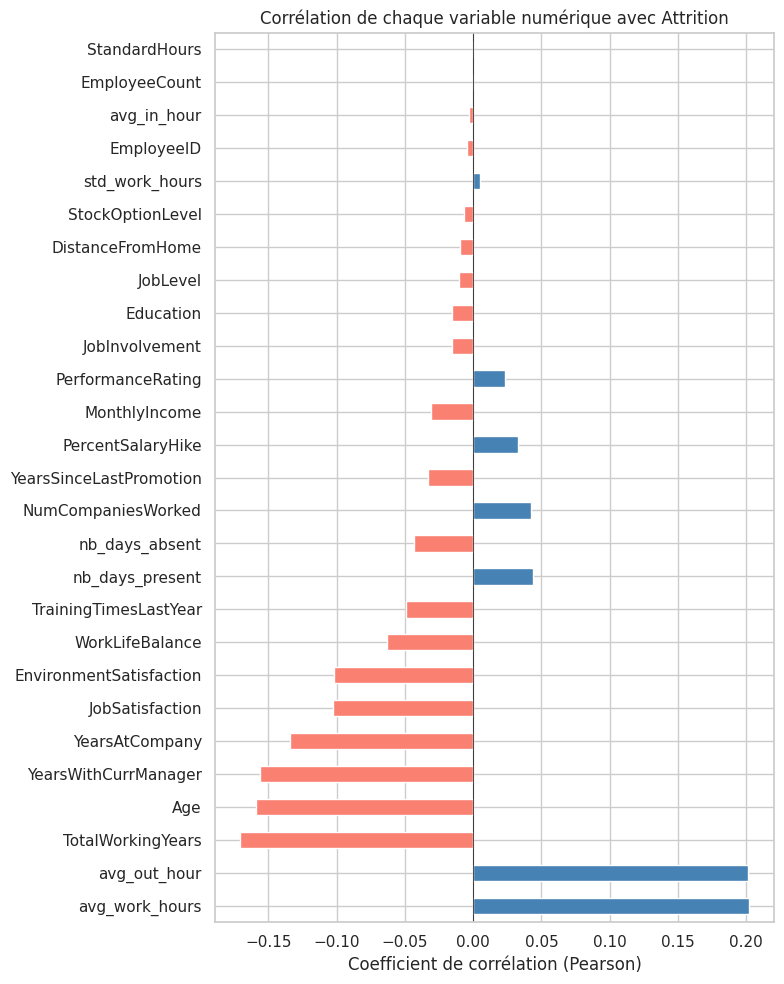

In [9]:
# Encoder Attrition en numérique pour calculer les corrélations
df["Attrition_binary"] = (df["Attrition"] == "Yes").astype(int)

num_cols = df.select_dtypes(include="number").columns.tolist()
correlations = df[num_cols].corr()["Attrition_binary"].drop("Attrition_binary")
correlations = correlations.reindex(correlations.abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(8, 10))
colors = ["salmon" if v < 0 else "steelblue" for v in correlations]
correlations.plot.barh(ax=ax, color=colors)
ax.set_title("Corrélation de chaque variable numérique avec Attrition")
ax.set_xlabel("Coefficient de corrélation (Pearson)")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

## 4.7 Résumé

Le DataFrame final `df` contient **4410 lignes** et combine :

| Source | Colonnes ajoutées | Type de jointure | Clé |
|---|---|---|---|
| `general_data.csv` | 24 cols (démographiques, salariales, carrière) | Table de base | `EmployeeID` |
| `employee_survey_data.csv` | 3 cols (satisfaction) | `LEFT JOIN` on `EmployeeID` | `EmployeeID` |
| `manager_survey_data.csv` | 2 cols (évaluation) | `LEFT JOIN` on `EmployeeID` | `EmployeeID` |
| `in_out_time/` (agrégé) | 6 cols (horaires) | `LEFT JOIN` on `EmployeeID` | index → `EmployeeID` |

Toutes les relations sont **1:1** (un enregistrement par employé dans chaque source).

In [10]:
print(f"DataFrame final : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\nColonnes :\n{list(df.columns)}")

DataFrame final : 4410 lignes × 36 colonnes

Colonnes :
['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeID', 'Gender', 'JobLevel', 'JobRole', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'Over18', 'PercentSalaryHike', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'avg_in_hour', 'avg_out_hour', 'avg_work_hours', 'std_work_hours', 'nb_days_present', 'nb_days_absent', 'Attrition_binary']
